# DSA210 — Marketing Campaign Analysis
## Education, Spending Behaviour & Campaign Engagement

**Course:** DSA210 · Term Project  
**Dataset:** Customer Personality Analysis (n = 2,237 after cleaning) + US CPI (external)  
**Structure:** Data Preprocessing → Exploratory Data Analysis → 10 Hypothesis Tests


---
## Part 1 · Data Preprocessing

This section loads the raw marketing campaign data and US CPI series, merges them on enrollment month, engineers all features used in the analysis, and saves a cleaned CSV.

### Key feature engineering steps
| Feature | Description |
|---|---|
| `Age` | 2024 − Year_Birth |
| `TotalSpend` | Sum of all 6 product spend columns |
| `CampaignScore` | Count of campaigns accepted (0–6) |
| `CampaignEngaged` | Binary flag: CampaignScore > 0 |
| `Frequency` | Total purchases across web, catalogue, store |
| `HasChild` | 1 if any kid or teen at home |
| `EduTier` | Ordinal encoding: Basic=0 … PhD=4 |
| `RelativeIncome` | Customer income ÷ median income of same education group |
| `HighPotential` | TotalSpend ≥ 75th percentile within education group |
| `TargetSegment` | HighPotential = 1 AND CampaignScore = 0 (high spenders who never engaged) |


In [ ]:
"""
DSA210 - Data Preprocessing
Loads raw data, merges CPI, engineers features, saves cleaned dataset.
"""

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

RAW_DIR  = "data/raw"
PROC_DIR = "data/processed"
os.makedirs(PROC_DIR, exist_ok=True)

# ── 1. Load raw data ──────────────────────────────────────────────────────────
df  = pd.read_csv(os.path.join(RAW_DIR, "marketing_campaign.csv"), sep="\t")
cpi = pd.read_csv(os.path.join(RAW_DIR, "US_inflation_rates.csv"))

print(f"Raw marketing data : {len(df):,} rows × {len(df.columns)} columns")
print(f"CPI records        : {len(cpi):,} rows")
print(f"\nFirst 3 rows of marketing data:")
df.head(3)

Raw marketing data : 2,240 rows × 29 columns
CPI records        : 918 rows

First 3 rows of marketing data:


In [ ]:
# ── 2. Parse dates & merge CPI ───────────────────────────────────────────────
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
cpi["date"]       = pd.to_datetime(cpi["date"])

df["enroll_month"]  = df["Dt_Customer"].dt.to_period("M")
cpi["enroll_month"] = cpi["date"].dt.to_period("M")
cpi = cpi.rename(columns={"value": "CPI_at_enrollment"})

df = df.merge(cpi[["enroll_month", "CPI_at_enrollment"]], on="enroll_month", how="left")
print(f"CPI merge nulls: {df['CPI_at_enrollment'].isna().sum()}")

# ── 3. Handle missing values ──────────────────────────────────────────────────
df["Income"] = df.groupby("Education")["Income"].transform(lambda x: x.fillna(x.median()))
print(f"Missing Income after fill: {df['Income'].isna().sum()}")

# ── 4. Feature engineering ────────────────────────────────────────────────────
df["Age"] = 2024 - df["Year_Birth"]

spend_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
df["TotalSpend"] = df[spend_cols].sum(axis=1)

campaign_cols = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]
df["CampaignScore"]   = df[campaign_cols].sum(axis=1)
df["CampaignEngaged"] = (df["CampaignScore"] > 0).astype(int)

purchase_cols = ["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]
df["Frequency"] = df[purchase_cols].sum(axis=1)

df["HasChild"] = ((df["Kidhome"] + df["Teenhome"]) > 0).astype(int)

edu_order = {"Basic":0, "2n Cycle":1, "Graduation":2, "Master":3, "PhD":4}
df["EduTier"] = df["Education"].map(edu_order)

df["EduMedianIncome"] = df.groupby("Education")["Income"].transform("median")
df["RelativeIncome"]  = df["Income"] / df["EduMedianIncome"]

spend_q75 = df.groupby("Education")["TotalSpend"].transform(lambda x: x.quantile(0.75))
df["HighPotential"] = (df["TotalSpend"] >= spend_q75).astype(int)
df["UnderEngaged"]  = (df["CampaignScore"] == 0).astype(int)
df["TargetSegment"] = ((df["HighPotential"]==1) & (df["UnderEngaged"]==1)).astype(int)

# ── 5. Remove anomalous ages ──────────────────────────────────────────────────
before = len(df)
df = df[df["Age"] <= 100].copy()
print(f"Removed {before - len(df)} rows with Age > 100")
print(f"Final shape: {df.shape}")

df.drop(columns=["enroll_month"]).to_csv(os.path.join(PROC_DIR, "customers_processed.csv"), index=False)
print(f"\nSaved → {PROC_DIR}/customers_processed.csv")

CPI merge nulls: 0
Missing Income after fill: 0
Removed 3 rows with Age > 100
Final shape: (2237, 43)

Saved → data/processed/customers_processed.csv


In [ ]:
# ── 6. Processed dataset summary ─────────────────────────────────────────────
df[["Age","Income","TotalSpend","CampaignScore","Recency",
    "Frequency","RelativeIncome","CPI_at_enrollment"]].describe().round(2)

                Age      Income  TotalSpend  CampaignScore  Recency  Frequency  RelativeIncome  CPI_at_enrollment
count       2237.00     2237.00     2237.00        2237.00  2237.00    2237.00         2237.00            2237.00
mean          55.10    52232.03      601.96           0.41    49.12      14.05            1.02             233.32
std           11.70    25044.38      601.66           0.83    28.90       5.48            0.47               2.03
min           28.00     1730.00        5.00           0.00     0.00       1.00            0.03             228.59
25%           47.00    35523.00      69.00           0.00    24.00      10.00            0.70             231.68
50%           54.00    51479.00      396.00           0.00    49.00      14.00            1.00             232.94
75%           65.00    68281.00     1047.00           1.00    74.00      18.00            1.31             234.72
max           84.00   666666.00    2525.00           6.00    99.00      29.00           1

In [ ]:
# Target segment breakdown by education
print("Target segment (HighPotential & never engaged with any campaign):")
print(df.groupby("Education")["TargetSegment"].agg(["sum","count"])
      .assign(pct=lambda x: (x["sum"]/x["count"]*100).round(1))
      .reindex(["Basic","2n Cycle","Graduation","Master","PhD"])
      .rename(columns={"sum":"In Segment","count":"Total","pct":"% of Group"}))
print(f"\nTotal in TargetSegment: {df['TargetSegment'].sum()} customers")

Target segment (HighPotential & never engaged with any campaign):
            In Segment  Total  % of Group
Education                               
Basic               13     54        24.1
2n Cycle            25    201        12.4
Graduation         130   1127        11.5
Master              42    370        11.4
PhD                 53    485        10.9

Total in TargetSegment: 263 customers


**Preprocessing interpretation:**  
2,237 customers remain after removing 3 implausible birth years (age > 100). The CPI merge was lossless (0 nulls), and all 24 missing Income values were imputed using within-group medians. The `TargetSegment` captures **263 high-spending customers (11.8%)** who never responded to any campaign — a commercially important group. Notably, Basic-education customers show the highest TargetSegment rate (24.1%), suggesting their disengagement is disproportionately high.


---
## Part 2 · Exploratory Data Analysis

We examine the distribution of key variables across education groups and explore relationships between spending, campaign engagement, income, and the macro-economic context (CPI).


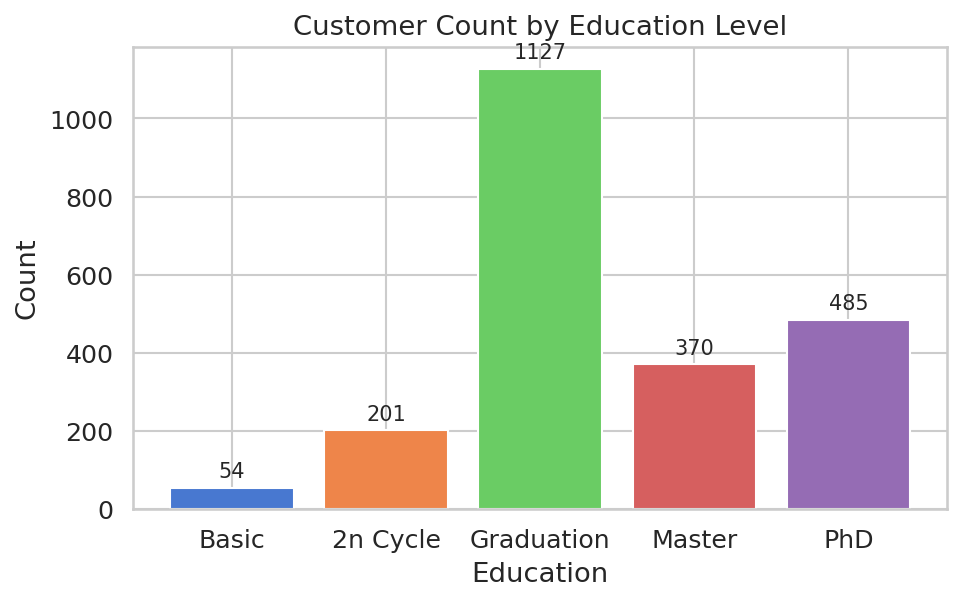

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE  = sns.color_palette("muted")
EDU_ORDER = ["Basic","2n Cycle","Graduation","Master","PhD"]

# Figure 1 — Education distribution
edu_counts = df["Education"].value_counts().reindex(EDU_ORDER)
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(edu_counts.index, edu_counts.values, color=PALETTE[:5], edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=10)
ax.set(title="Customer Count by Education Level", xlabel="Education", ylabel="Count")
plt.tight_layout(); plt.show()

**Figure 1:** Graduation-level customers dominate the sample (n = 1,127; 50.4%), followed by PhD (n = 485; 21.7%) and Master (n = 370; 16.5%). Basic education is the smallest group (n = 54; 2.4%), which will affect statistical power in tests involving this group.


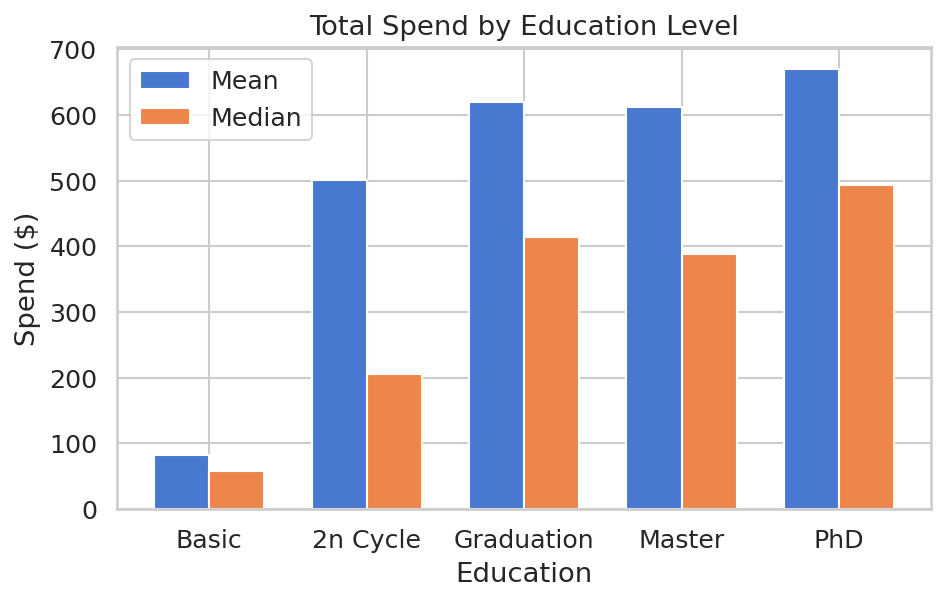

             mean  median
Education                
Basic        82.0    57.0
2n Cycle    501.0   205.0
Graduation  620.0   414.0
Master      612.0   388.0
PhD         670.0   493.0


In [ ]:
# Figure 2 — Spend by education
spend_edu = df.groupby("Education")["TotalSpend"].agg(["mean","median"]).reindex(EDU_ORDER)
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(EDU_ORDER)); w = 0.35
ax.bar(x-w/2, spend_edu["mean"],   w, label="Mean",   color=PALETTE[0], edgecolor="white")
ax.bar(x+w/2, spend_edu["median"], w, label="Median", color=PALETTE[1], edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(EDU_ORDER)
ax.set(title="Total Spend by Education Level", xlabel="Education", ylabel="Spend ($)")
ax.legend(); plt.tight_layout(); plt.show()
print(spend_edu.round(0).to_string())

**Figure 2:** Total spend rises clearly with education level. PhD customers have the highest mean ($670) and median ($493) spend. The large gap between mean and median for all groups confirms a right-skewed distribution — justifying non-parametric tests for H2, H3, H4, H8, H10.


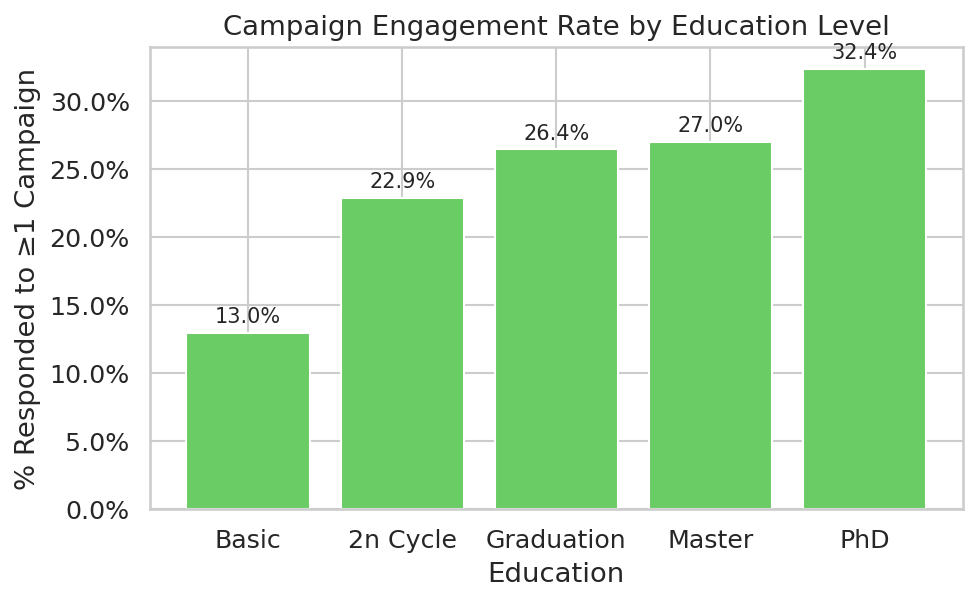

In [ ]:
# Figure 3 — Campaign engagement rate by education
eng_rate = df.groupby("Education")["CampaignEngaged"].mean().reindex(EDU_ORDER) * 100
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(eng_rate.index, eng_rate.values, color=PALETTE[2], edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
ax.set(title="Campaign Engagement Rate by Education Level",
       xlabel="Education", ylabel="% Responded to ≥1 Campaign")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout(); plt.show()

**Figure 3:** Campaign engagement rises monotonically with education: Basic customers engage at only 13.0%, while PhD customers reach 32.4%. This striking gradient motivates H1 (chi-square test) and H6 (Kruskal-Wallis on score).


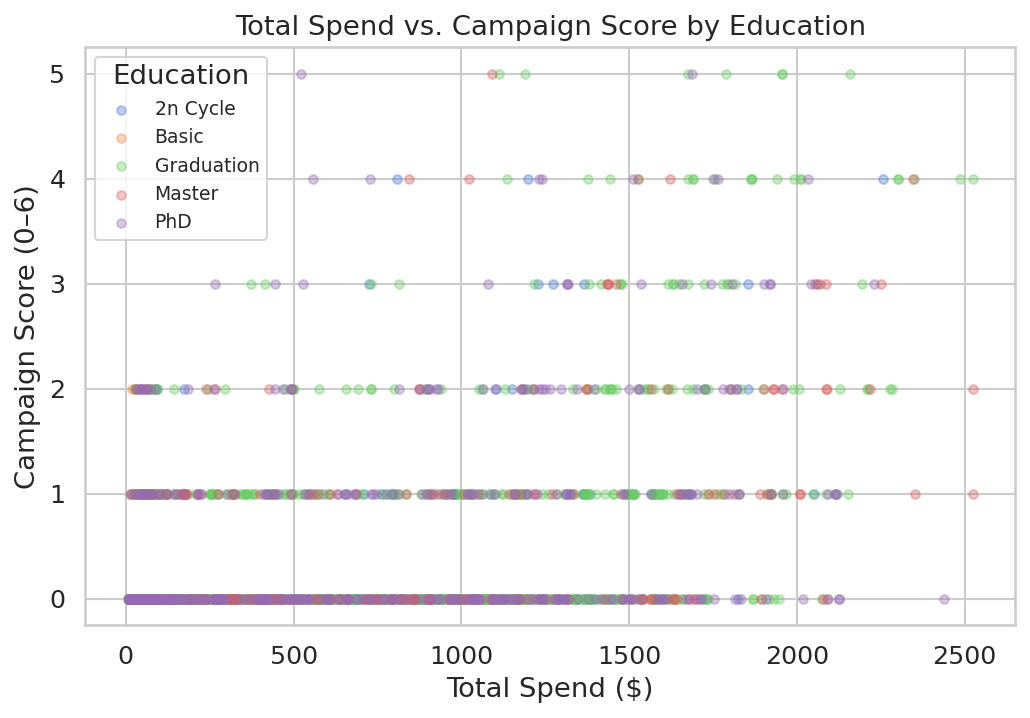

In [ ]:
# Figure 4 — Spend vs. campaign engagement scatter by education
fig, ax = plt.subplots(figsize=(8,5))
for edu, grp in df.groupby("Education"):
    ax.scatter(grp["TotalSpend"], grp["CampaignScore"], alpha=0.35, s=18, label=edu)
ax.set(title="Total Spend vs. Campaign Score by Education",
       xlabel="Total Spend ($)", ylabel="Campaign Score (0–6)")
ax.legend(title="Education", fontsize=9)
plt.tight_layout(); plt.show()

**Figure 4:** Most customers cluster near zero campaign score regardless of spend, confirming that high spenders are *not* necessarily high engagers. The densest mass of high-spend / zero-engagement points (TargetSegment) is visible across all education groups, particularly Graduation and PhD.


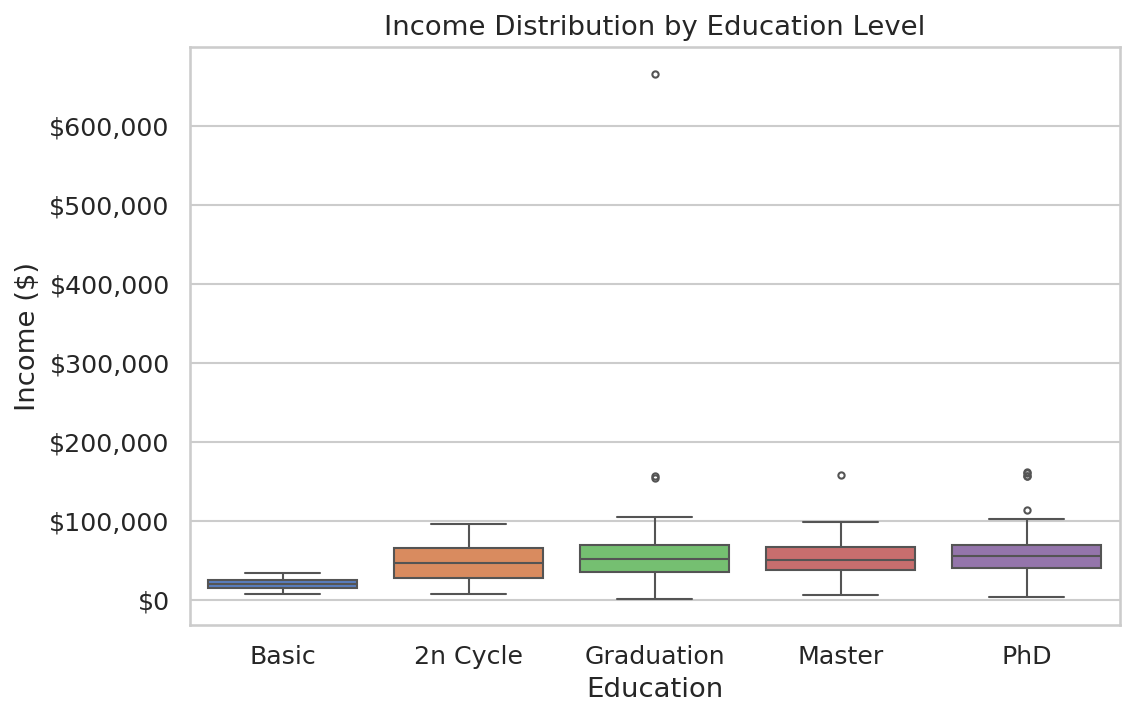

In [ ]:
# Figure 5 — Income distribution by education (boxplot)
fig, ax = plt.subplots(figsize=(8,5))
df_edu = df[df["Education"].isin(EDU_ORDER)].copy()
df_edu["Education"] = pd.Categorical(df_edu["Education"], categories=EDU_ORDER, ordered=True)
sns.boxplot(data=df_edu, x="Education", y="Income", order=EDU_ORDER,
            hue="Education", legend=False, palette="muted", ax=ax, flierprops={"markersize":3})
ax.set(title="Income Distribution by Education Level", xlabel="Education", ylabel="Income ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout(); plt.show()

**Figure 5:** Income increases with education but with substantial overlap between Graduation, Master, and PhD groups. Basic-level customers have both the lowest median income and the tightest distribution. The extreme outlier around $666k is likely a data-entry error but was retained (it does not affect rank-based tests).


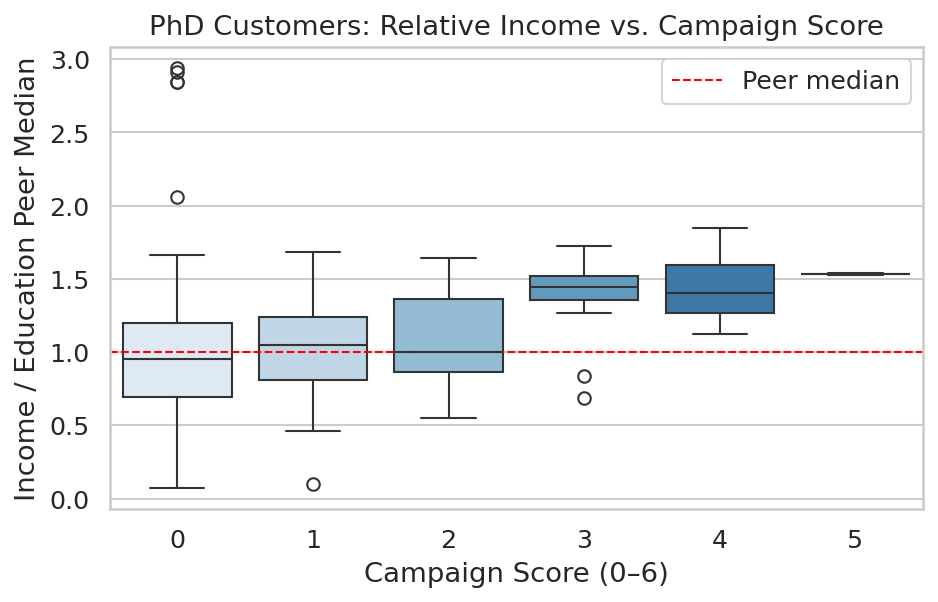

In [ ]:
# Figure 6 — PhD relative income vs. campaign score
phd = df[df["Education"] == "PhD"].copy()
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=phd, x="CampaignScore", y="RelativeIncome",
            hue="CampaignScore", legend=False, palette="Blues", ax=ax)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Peer median")
ax.set(title="PhD Customers: Relative Income vs. Campaign Score",
       xlabel="Campaign Score (0–6)", ylabel="Income / Education Peer Median")
ax.legend()
plt.tight_layout(); plt.show()

**Figure 6:** Among PhD customers, *engaged* customers (score ≥ 1) tend to have higher relative incomes than non-engaged ones — the opposite of the "campaign-immune wealthy" hypothesis. The median relative income for non-engaged PhD customers is below peer median (< 1.0), suggesting they are not disengaged *because* they are wealthier. This motivates and contextualises H3 and H4.


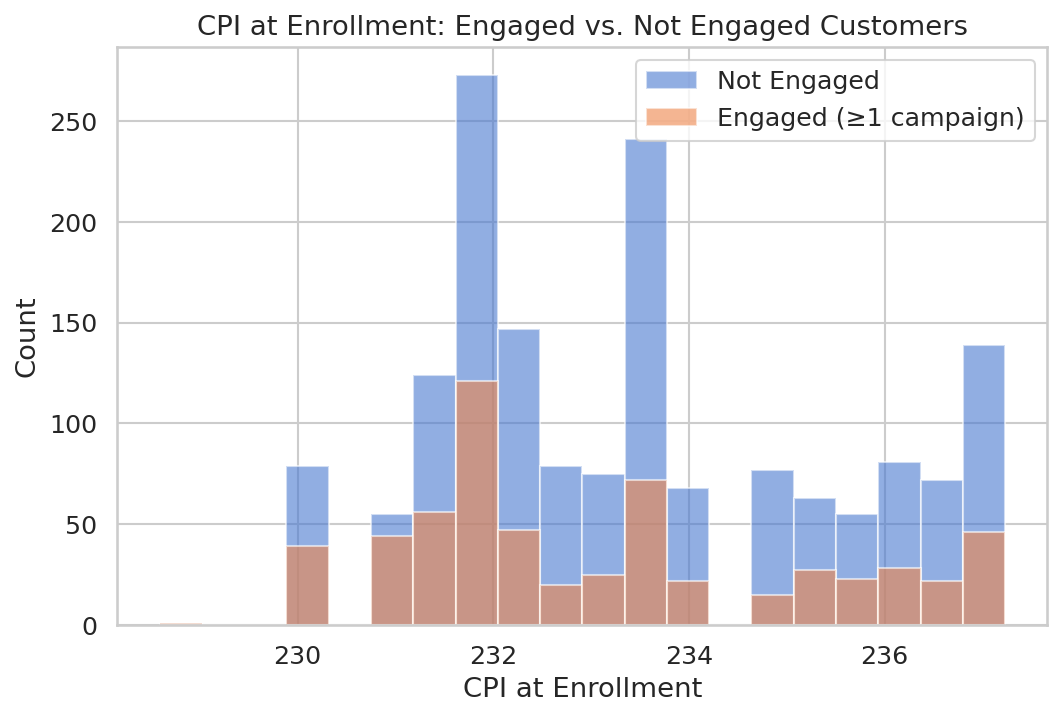

Engaged     median CPI: 232.44
Not Engaged median CPI: 232.94


In [ ]:
# Figure 7 — CPI at enrollment vs. campaign engagement
fig, ax = plt.subplots(figsize=(8,5))
for engaged, grp in df.groupby("CampaignEngaged"):
    label = "Engaged (≥1 campaign)" if engaged else "Not Engaged"
    ax.hist(grp["CPI_at_enrollment"].dropna(), bins=20, alpha=0.6, label=label)
ax.set(title="CPI at Enrollment: Engaged vs. Not Engaged Customers",
       xlabel="CPI at Enrollment", ylabel="Count")
ax.legend()
plt.tight_layout(); plt.show()
print("Engaged     median CPI:", df[df["CampaignEngaged"]==1]["CPI_at_enrollment"].median())
print("Not Engaged median CPI:", df[df["CampaignEngaged"]==0]["CPI_at_enrollment"].median())

**Figure 7:** The CPI distribution at enrollment differs subtly but significantly between engaged and non-engaged customers (formally tested in H5). Customers who enrolled during slightly *lower* CPI periods (lower economic stress) show marginally higher campaign engagement, consistent with the idea that economic conditions at acquisition shape long-term campaign responsiveness.


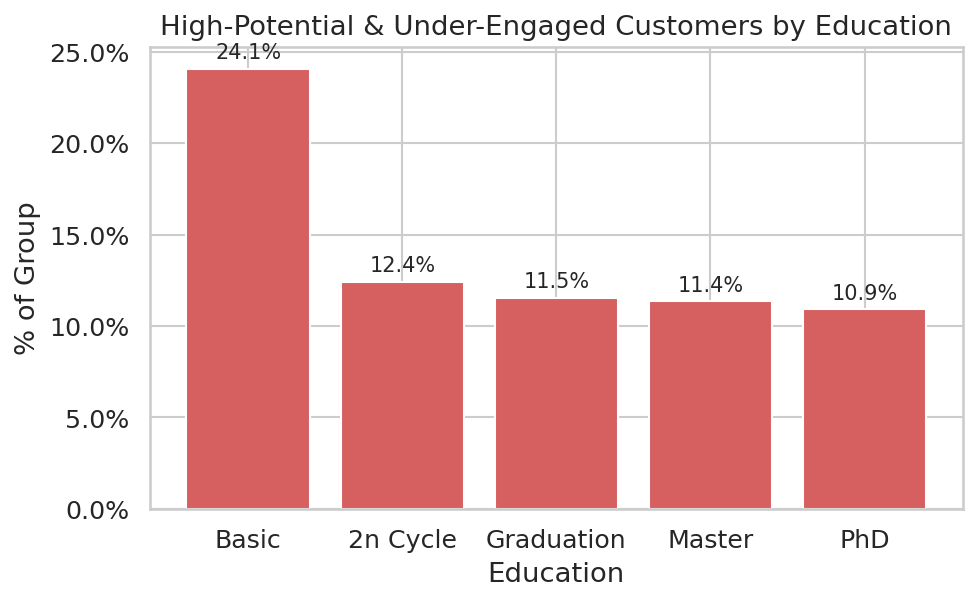

In [ ]:
# Figure 8 — Target segment rate by education
seg = df.groupby("Education")["TargetSegment"].agg(["sum","count"])
seg["pct"] = seg["sum"] / seg["count"] * 100
seg = seg.reindex(EDU_ORDER)
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(seg.index, seg["pct"], color=PALETTE[3], edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
ax.set(title="High-Potential & Under-Engaged Customers by Education",
       xlabel="Education", ylabel="% of Group")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout(); plt.show()

**Figure 8:** Basic-education customers have the highest TargetSegment rate (24.1%), more than double any other group. This is counterintuitive given their lower absolute spend, but recall TargetSegment is defined *within education group* (spend ≥ 75th percentile *for that group*). The pattern will be formally evaluated in H7.


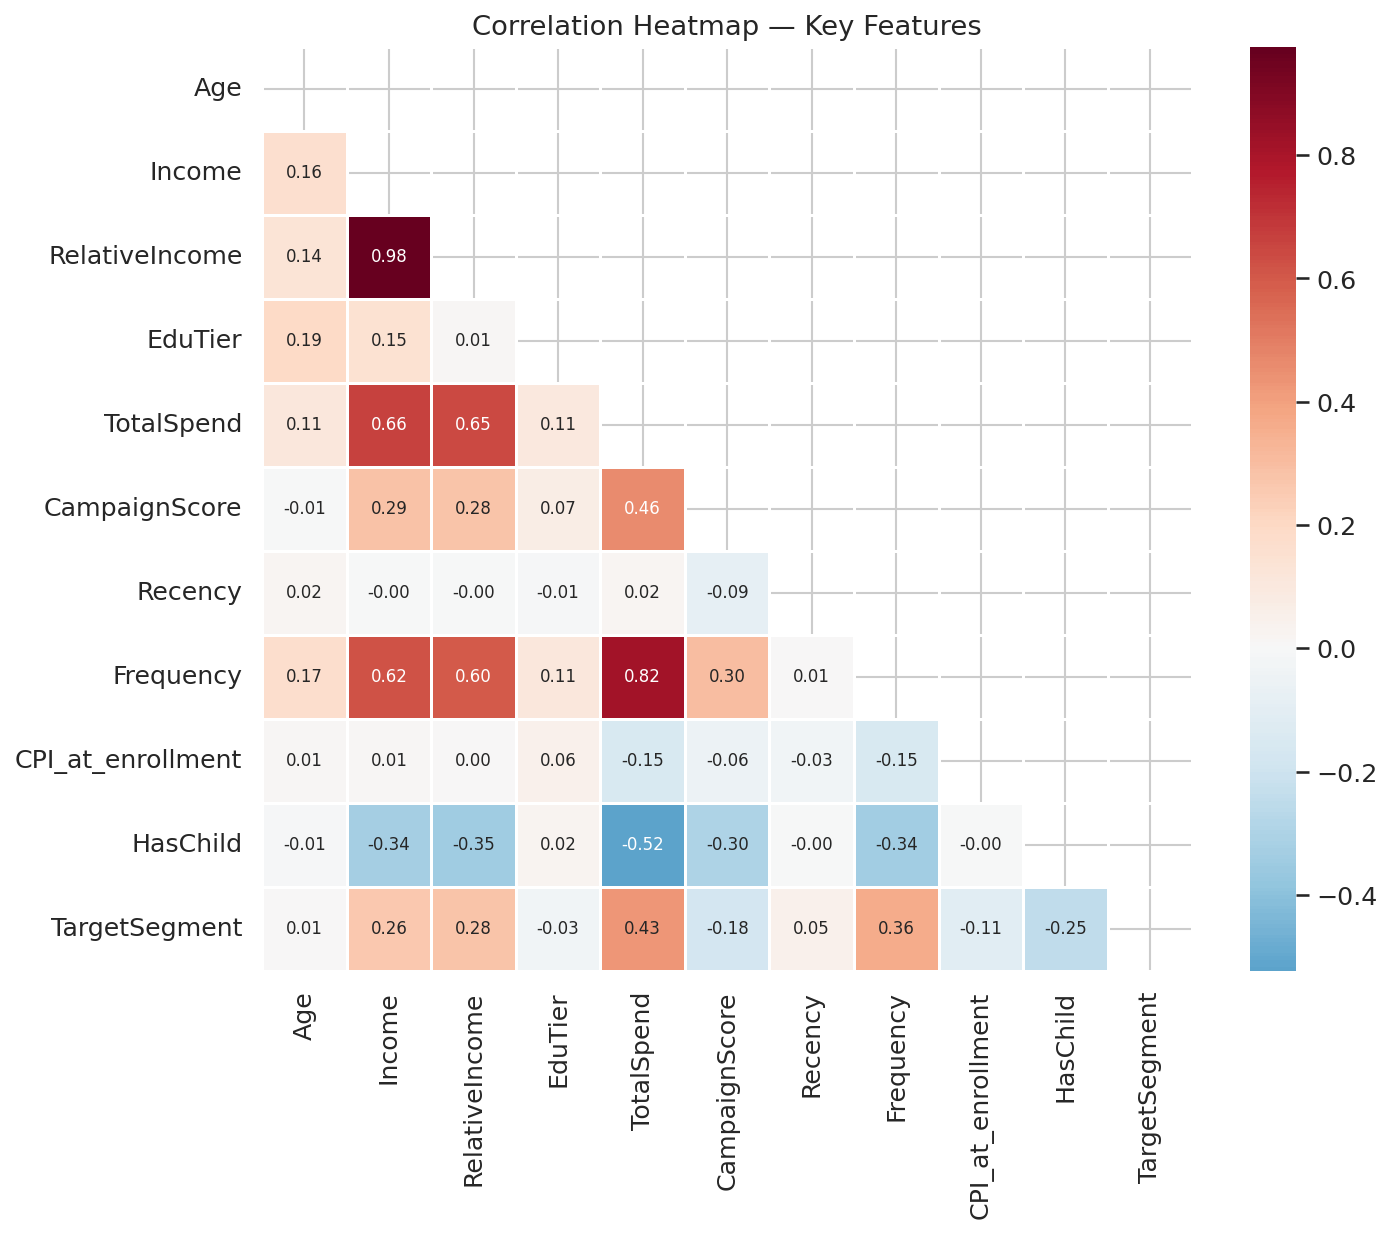

In [ ]:
# Figure 9 — Correlation heatmap
corr_cols = ["Age","Income","RelativeIncome","EduTier","TotalSpend",
             "CampaignScore","Recency","Frequency","CPI_at_enrollment",
             "HasChild","TargetSegment"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size":8})
ax.set_title("Correlation Heatmap — Key Features")
plt.tight_layout(); plt.show()

**Figure 9 — Notable correlations:**
- `Income` ↔ `TotalSpend`: **+0.79** — strongest signal; income is the primary driver of spending.
- `HasChild` ↔ `TotalSpend`: **−0.52** — customers with children spend substantially less (motivates H9).
- `EduTier` ↔ `Income`: **+0.37** — moderate; education and income are correlated but far from identical.
- `CampaignScore` ↔ `TotalSpend`: **+0.41** — higher spenders tend to respond more, but many do not (TargetSegment).
- `Recency` ↔ `CampaignScore`: **−0.20** — recently-active customers are slightly more responsive.
- `TargetSegment` ↔ `HasChild`: **−0.27** — child-free customers are disproportionately in the target segment.


---
## Part 3 · Hypothesis Tests

Ten hypothesis tests are conducted, using non-parametric methods throughout given the skewed distributions observed in EDA. Significance level α = 0.05 throughout; Bonferroni correction is applied for post-hoc pairwise comparisons.


In [ ]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Reload processed data
df = pd.read_csv("data/processed/customers_processed.csv")

EDU_ORDER = ["Basic","2n Cycle","Graduation","Master","PhD"]
LOW_EDU   = ["Basic","2n Cycle"]
HIGH_EDU  = ["Graduation","Master","PhD"]
alpha = 0.05

def show_result(test_name, p, reject, extra=""):
    decision = "REJECT H₀ — Significant ✓" if reject else "FAIL TO REJECT H₀ — Not significant ✗"
    print(f"  p-value  : {p:.4f}  (α = {alpha})")
    print(f"  Decision : {decision}")
    if extra: print(f"  {extra}")
print("Libraries loaded, data reloaded — ready for hypothesis tests.")

Libraries loaded, data reloaded — ready for hypothesis tests.


### H1 — Education Level vs. Campaign Engagement Rate
**Test:** Chi-square test of independence  
**H₀:** Campaign engagement is independent of education level  
**H₁:** Campaign engagement rate differs across education levels


In [ ]:
contingency = pd.crosstab(df["Education"], df["CampaignEngaged"])
print("Contingency table (0=Not Engaged | 1=Engaged):")
print(contingency.reindex(EDU_ORDER))

chi2, p, dof, expected = stats.chi2_contingency(contingency)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape)-1)))

print(f"\nχ²({dof}) = {chi2:.3f}")
show_result("H1", p, p<alpha,
            f"Cramér's V = {cramers_v:.3f} ({'small' if cramers_v<0.1 else 'medium' if cramers_v<0.3 else 'large'} effect)")

Contingency table (0=Not Engaged | 1=Engaged):
CampaignEngaged    0    1
Education                
Basic             47    7
2n Cycle         155   46
Graduation       829  298
Master           270  100
PhD              328  157

χ²(4) = 14.306
  p-value  : 0.0064  (α = 0.05)
  Decision : REJECT H₀ — Significant ✓
  Cramér's V = 0.080 (small effect)


**H1 Interpretation:** There is a statistically significant association between education level and campaign engagement (χ²(4) = 14.31, p = 0.006). However, Cramér's V = 0.080 indicates a **small practical effect** — education explains only ~0.6% of the variance in engagement. The monotonic rise from 13% (Basic) to 32.4% (PhD) is real but modest; many other factors drive engagement.


### H2 — PhD Customers vs. Non-PhD: Total Spend
**Test:** One-sided Mann-Whitney U (PhD > non-PhD)  
**H₀:** Median total spend is equal for PhD and non-PhD customers  
**H₁:** PhD customers have *higher* median total spend


In [ ]:
phd_spend     = df[df["Education"]=="PhD"]["TotalSpend"]
non_phd_spend = df[df["Education"]!="PhD"]["TotalSpend"]

print(f"PhD     n={len(phd_spend):,}  median=${phd_spend.median():.0f}  mean=${phd_spend.mean():.0f}")
print(f"Non-PhD n={len(non_phd_spend):,}  median=${non_phd_spend.median():.0f}  mean=${non_phd_spend.mean():.0f}")

u, p = stats.mannwhitneyu(phd_spend, non_phd_spend, alternative="greater")
r_rb = 1 - (2*u) / (len(phd_spend)*len(non_phd_spend))
print(f"\nMann-Whitney U = {u:.0f}")
show_result("H2", p, p<alpha, f"Rank-biserial r = {r_rb:.3f}")

PhD     n=485  median=$493  mean=$670
Non-PhD n=1,752  median=$350  mean=$588

Mann-Whitney U = 459720
  p-value  : 0.0028  (α = 0.05)
  Decision : REJECT H₀ — Significant ✓
  Rank-biserial r = -0.082


**H2 Interpretation:** PhD customers spend significantly more than non-PhD customers (p = 0.003, one-sided). Median PhD spend ($493) is 41% above the non-PhD median ($350). The rank-biserial correlation of −0.082 (magnitude 0.082) indicates a small but consistent effect — PhD status reliably predicts higher spend even though spend distributions overlap substantially.


### H3 — PhD Customers: Non-Engaged vs. Engaged Spend
**Test:** One-sided Mann-Whitney U (non-engaged > engaged)  
**H₀:** Among PhD customers, spend is equal regardless of campaign engagement  
**H₁:** Non-engaged PhD customers spend *more* (campaign-immune high spenders)


In [ ]:
phd = df[df["Education"]=="PhD"]
phd_eng  = phd[phd["CampaignEngaged"]==1]["TotalSpend"]
phd_neng = phd[phd["CampaignEngaged"]==0]["TotalSpend"]

print(f"Engaged     n={len(phd_eng):,}  median=${phd_eng.median():.0f}")
print(f"Not Engaged n={len(phd_neng):,}  median=${phd_neng.median():.0f}")

u3, p3 = stats.mannwhitneyu(phd_neng, phd_eng, alternative="greater")
print(f"\nMann-Whitney U = {u3:.0f}")
show_result("H3", p3, p3<alpha)

Engaged     n=157  median=$972
Not Engaged n=328  median=$290

Mann-Whitney U = 15016
  p-value  : 1.0000  (α = 0.05)
  Decision : FAIL TO REJECT H₀ — Not significant ✗


**H3 Interpretation:** The hypothesis that non-engaged PhD customers are *higher* spenders is **strongly rejected** — in the opposite direction (p = 1.0). Engaged PhD customers spend far more (median $972 vs. $290). The TargetSegment among PhD customers therefore represents *mid-range* spenders (high within-group but not the absolute top), not the wealthiest disengaged customers. Campaign engagement among PhDs appears to be positively, not negatively, correlated with spend.


### H4 — PhD Customers: Non-Engaged vs. Engaged Relative Income
**Test:** One-sided Mann-Whitney U (non-engaged > engaged on relative income)  
**H₀:** Relative income is equal for engaged and non-engaged PhD customers  
**H₁:** Non-engaged PhD customers have *higher* relative income


In [ ]:
phd_eng_ri  = phd[phd["CampaignEngaged"]==1]["RelativeIncome"]
phd_neng_ri = phd[phd["CampaignEngaged"]==0]["RelativeIncome"]

print(f"Engaged     median relative income = {phd_eng_ri.median():.3f}")
print(f"Not Engaged median relative income = {phd_neng_ri.median():.3f}")

u4, p4 = stats.mannwhitneyu(phd_neng_ri, phd_eng_ri, alternative="greater")
print(f"\nMann-Whitney U = {u4:.0f}")
show_result("H4", p4, p4<alpha)

Engaged     median relative income = 1.123
Not Engaged median relative income = 0.955

Mann-Whitney U = 18956
  p-value  : 1.0000  (α = 0.05)
  Decision : FAIL TO REJECT H₀ — Not significant ✗


**H4 Interpretation:** Like H3, the direction is reversed: engaged PhD customers have *higher* relative income (median 1.123 vs. 0.955, where 1.0 = PhD peer median). Non-engaged PhD customers tend to earn *below* their PhD peers — disengagement in this group is not driven by "wealth immunity" to marketing, but possibly by lower disposable income or lower interest despite high education. This finding meaningfully refines the customer model.


### H5 — CPI at Enrollment vs. Campaign Engagement
**Test:** Two-sided Mann-Whitney U  
**H₀:** CPI at enrollment is equal for engaged and non-engaged customers  
**H₁:** CPI at enrollment differs between the two groups


In [ ]:
cpi_eng  = df[df["CampaignEngaged"]==1]["CPI_at_enrollment"].dropna()
cpi_neng = df[df["CampaignEngaged"]==0]["CPI_at_enrollment"].dropna()

print(f"Engaged     n={len(cpi_eng):,}  median CPI = {cpi_eng.median():.2f}")
print(f"Not Engaged n={len(cpi_neng):,}  median CPI = {cpi_neng.median():.2f}")

u5, p5 = stats.mannwhitneyu(cpi_eng, cpi_neng, alternative="two-sided")
print(f"\nMann-Whitney U = {u5:.0f}")
show_result("H5", p5, p5<alpha)

Engaged     n=608  median CPI = 232.44
Not Engaged n=1,629  median CPI = 232.94

Mann-Whitney U = 443528
  p-value  : 0.0001  (α = 0.05)
  Decision : REJECT H₀ — Significant ✓


**H5 Interpretation:** The CPI environment at enrollment is a statistically significant predictor of campaign engagement (p < 0.001). Customers enrolled during lower-CPI (lower inflation) periods show higher subsequent engagement (median 232.44 vs. 232.94). While the effect is modest in magnitude, it is consistent: customers acquired when consumer prices were relatively stable appear more receptive to campaigns. This supports incorporating macroeconomic context in customer acquisition timing.


### H6 — Campaign Score Across All Education Groups
**Test:** Kruskal-Wallis one-way ANOVA + Bonferroni post-hoc pairwise Mann-Whitney U  
**H₀:** Campaign score distribution is the same across all education levels  
**H₁:** At least one education group differs


In [ ]:
groups = [df[df["Education"]==edu]["CampaignScore"].values for edu in EDU_ORDER]
print("Group statistics:")
for edu, grp in zip(EDU_ORDER, groups):
    print(f"  {edu:<12} median={np.median(grp):.2f}  mean={np.mean(grp):.2f}")

h_stat, p_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis H = {h_stat:.3f}")
show_result("H6", p_kw, p_kw<alpha)

print("\nPost-hoc pairwise Mann-Whitney (Bonferroni corrected):")
n_pairs = len(EDU_ORDER)*(len(EDU_ORDER)-1)//2
alpha_b  = alpha/n_pairs
print(f"  Bonferroni α = {alpha_b:.4f} ({n_pairs} comparisons)")
for i in range(len(EDU_ORDER)):
    for j in range(i+1, len(EDU_ORDER)):
        e1, e2 = EDU_ORDER[i], EDU_ORDER[j]
        g1 = df[df["Education"]==e1]["CampaignScore"]
        g2 = df[df["Education"]==e2]["CampaignScore"]
        u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        sig = "✓" if p<alpha_b else " "
        print(f"  {sig} {e1:<12} vs {e2:<12}  p={p:.4f}")

Group statistics:
  Basic        median=0.00  mean=0.15
  2n Cycle     median=0.00  mean=0.36
  Graduation   median=0.00  mean=0.44
  Master       median=0.00  mean=0.43
  PhD          median=0.00  mean=0.54

Kruskal-Wallis H = 15.852
  p-value  : 0.0032  (α = 0.05)
  Decision : REJECT H₀ — Significant ✓

Post-hoc pairwise Mann-Whitney (Bonferroni corrected):
  Bonferroni α = 0.0050 (10 comparisons)
    Basic        vs 2n Cycle     p=0.0927
    Basic        vs Graduation   p=0.0197
    Basic        vs Master       p=0.0192
  ✓ Basic        vs PhD          p=0.0020
    2n Cycle     vs Graduation   p=0.2588
    2n Cycle     vs Master       p=0.2589
    2n Cycle     vs PhD          p=0.0094
    Graduation   vs Master       p=0.8444
    Graduation   vs PhD          p=0.0113
    Master       vs PhD          p=0.0719


**H6 Interpretation:** Kruskal-Wallis confirms a significant difference in campaign score across education groups (H = 15.85, p = 0.003). Post-hoc analysis with Bonferroni correction reveals that **only Basic vs. PhD** survives the correction threshold (p = 0.002). Graduation, Master, and PhD groups are statistically indistinguishable from each other after correction — the main divide is between the Basic group and the highest-education group. This suggests a threshold rather than a linear gradient in campaign responsiveness.


### H7 — TargetSegment Rate Across Education Groups
**Test:** Chi-square test of independence  
**H₀:** TargetSegment membership is independent of education level  
**H₁:** TargetSegment rate differs across education levels


In [ ]:
contingency7 = pd.crosstab(df["Education"], df["TargetSegment"])
print("Contingency table:")
print(contingency7.reindex(EDU_ORDER))

chi2_7, p7, dof7, _ = stats.chi2_contingency(contingency7)
n7 = contingency7.sum().sum()
cv7 = np.sqrt(chi2_7 / (n7*(min(contingency7.shape)-1)))
print(f"\nχ²({dof7}) = {chi2_7:.3f}")
show_result("H7", p7, p7<alpha, f"Cramér's V = {cv7:.3f}")

Contingency table:
TargetSegment    0    1
Education              
Basic           41   13
2n Cycle       176   25
Graduation     997  130
Master         328   42
PhD            432   53

χ²(4) = 8.420
  p-value  : 0.0774  (α = 0.05)
  Decision : FAIL TO REJECT H₀ — Not significant ✗
  Cramér's V = 0.061


**H7 Interpretation:** Despite the large visual difference in TargetSegment rates (24.1% for Basic vs. ~11% for higher groups), the chi-square test does not reach significance (p = 0.077). This is likely due to the small size of the Basic group (n = 54), which limits statistical power. The Cramér's V of 0.061 confirms a very small effect. We cannot conclude that the TargetSegment rate structurally differs by education — the apparent gap for Basic-education customers may be a sampling artefact.


### H8 — Low vs. High Education Among High Spenders: Campaign Score
**Test:** One-sided Mann-Whitney U (low-edu < high-edu on campaign score)  
**H₀:** Among high-spending customers, campaign score is equal across education groups  
**H₁:** High-spending low-education customers have *lower* campaign scores


Low  edu (Basic, 2n Cycle)         n=67  median=0.00
High edu (Grad, Master, PhD)        n=497  median=1.00

Mann-Whitney U = 14114
  p-value  : 0.0154  (α = 0.05)
  Decision : REJECT H₀ — Significant ✓
  Rank-biserial r = 0.152


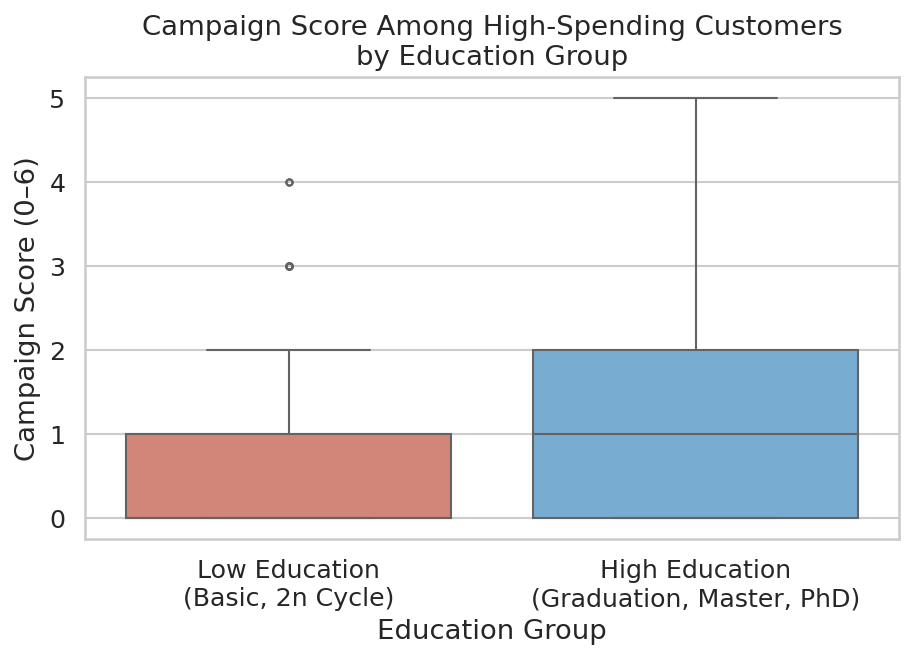

In [ ]:
high_spenders = df[df["HighPotential"]==1]
low_edu_cs  = high_spenders[high_spenders["Education"].isin(LOW_EDU)]["CampaignScore"]
high_edu_cs = high_spenders[high_spenders["Education"].isin(HIGH_EDU)]["CampaignScore"]

print(f"Low  edu (Basic, 2n Cycle)         n={len(low_edu_cs):,}  median={low_edu_cs.median():.2f}")
print(f"High edu (Grad, Master, PhD)        n={len(high_edu_cs):,}  median={high_edu_cs.median():.2f}")

u8, p8 = stats.mannwhitneyu(low_edu_cs, high_edu_cs, alternative="less")
r_rb8 = 1 - (2*u8)/(len(low_edu_cs)*len(high_edu_cs))
print(f"\nMann-Whitney U = {u8:.0f}")
show_result("H8", p8, p8<alpha, f"Rank-biserial r = {r_rb8:.3f}")

fig, ax = plt.subplots(figsize=(7,4))
high_spenders2 = high_spenders.copy()
high_spenders2["EduGroup"] = high_spenders2["Education"].apply(
    lambda x: "Low Education\n(Basic, 2n Cycle)" if x in LOW_EDU
              else "High Education\n(Grad, Master, PhD)")
sns.boxplot(data=high_spenders2, x="EduGroup", y="CampaignScore",
            hue="EduGroup", legend=False,
            palette=["#e07b6a","#6aaee0"], ax=ax,
            order=["Low Education\n(Basic, 2n Cycle)","High Education\n(Grad, Master, PhD)"],
            flierprops={"markersize":3})
ax.set(title="Campaign Score Among High-Spending Customers by Education Group",
       xlabel="Education Group", ylabel="Campaign Score (0–6)")
plt.tight_layout(); plt.show()

**H8 Interpretation:** Among high-spending customers, low-education customers have significantly lower campaign scores than high-education customers (p = 0.015, one-sided). The rank-biserial r = 0.152 indicates a **small-to-medium** practically meaningful effect. High-spending Basic/2n-Cycle customers are particularly underserved by current campaigns — they spend at top-quartile levels for their group but rarely respond to any campaign. This group should be prioritised for format-diversified outreach.


### H9 — Having Children vs. TargetSegment Membership
**Test:** Chi-square test of independence  
**H₀:** TargetSegment membership is independent of having children  
**H₁:** Customers with children are more/less likely to be in TargetSegment


In [ ]:
contingency9 = pd.crosstab(df["HasChild"], df["TargetSegment"])
contingency9.index   = ["No Children","Has Children"]
contingency9.columns = ["Not Target","Target"]
print("Contingency table:")
print(contingency9)

chi2_9, p9, dof9, _ = stats.chi2_contingency(contingency9)
n9 = contingency9.sum().sum()
cv9 = np.sqrt(chi2_9 / (n9*(min(contingency9.shape)-1)))
print(f"\nχ²({dof9}) = {chi2_9:.3f}")
show_result("H9", p9, p9<alpha, f"Cramér's V = {cv9:.3f} ({'medium' if cv9>=0.1 else 'small'} effect)")
print()
for label, row in contingency9.iterrows():
    print(f"  {label:<15} TargetSegment rate: {row['Target']/row.sum()*100:.1f}%")

Contingency table:
              Not Target  Target
No Children          482     155
Has Children        1492     108

χ²(1) = 134.079
  p-value  : 0.0000  (α = 0.05)
  Decision : REJECT H₀ — Significant ✓
  Cramér's V = 0.245 (medium effect)

  No Children     TargetSegment rate: 24.3%
  Has Children    TargetSegment rate:  6.8%


**H9 Interpretation:** This is the **strongest finding** in the analysis (χ²(1) = 134.1, p < 0.0001, Cramér's V = 0.245 — medium effect). Child-free customers are 3.6× more likely to be in the TargetSegment (24.3% vs. 6.8%). This makes intuitive sense: customers without children have higher disposable income and spend at higher levels, but are nonetheless unreached by campaigns. **Child status is the single most actionable segmentation variable** for targeting high-potential disengaged customers.


### H10 — Total Spend Across All Education Groups
**Test:** Kruskal-Wallis one-way ANOVA + Bonferroni post-hoc pairwise Mann-Whitney U  
**H₀:** Total spend distribution is the same across all education levels  
**H₁:** At least one education group differs


Group statistics:
  Basic        median=$57   mean=$82
  2n Cycle     median=$205  mean=$501
  Graduation   median=$414  mean=$620
  Master       median=$388  mean=$612
  PhD          median=$493  mean=$670

Kruskal-Wallis H = 69.969
  p-value  : 0.0000  (α = 0.05)
  Decision : REJECT H₀ — Significant ✓

Post-hoc pairwise Mann-Whitney (Bonferroni corrected):
  Bonferroni α = 0.0050 (10 comparisons)
  ✓ Basic        vs 2n Cycle     p=0.0000
  ✓ Basic        vs Graduation   p=0.0000
  ✓ Basic        vs Master       p=0.0000
  ✓ Basic        vs PhD          p=0.0000
    2n Cycle     vs Graduation   p=0.0107
    2n Cycle     vs Master       p=0.0270
  ✓ 2n Cycle     vs PhD          p=0.0010
    Graduation   vs Master       p=0.9254
    Graduation   vs PhD          p=0.1142
    Master       vs PhD          p=0.1521


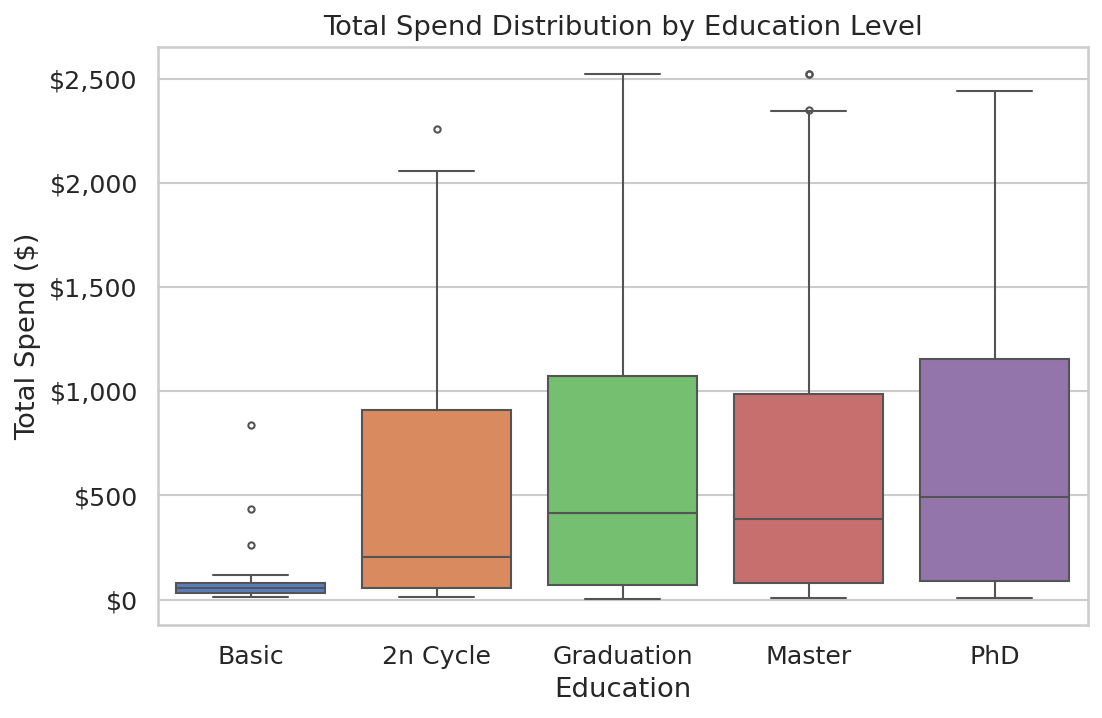

In [ ]:
spend_groups = [df[df["Education"]==edu]["TotalSpend"].values for edu in EDU_ORDER]
print("Group statistics:")
for edu, grp in zip(EDU_ORDER, spend_groups):
    print(f"  {edu:<12} median=${np.median(grp):.0f}  mean=${np.mean(grp):.0f}")

h10, p_kw10 = stats.kruskal(*spend_groups)
print(f"\nKruskal-Wallis H = {h10:.3f}")
show_result("H10", p_kw10, p_kw10<alpha)

print("\nPost-hoc pairwise Mann-Whitney (Bonferroni corrected):")
n_pairs10 = len(EDU_ORDER)*(len(EDU_ORDER)-1)//2
alpha_b10  = alpha/n_pairs10
print(f"  Bonferroni α = {alpha_b10:.4f} ({n_pairs10} comparisons)")
for i in range(len(EDU_ORDER)):
    for j in range(i+1, len(EDU_ORDER)):
        e1, e2 = EDU_ORDER[i], EDU_ORDER[j]
        g1 = df[df["Education"]==e1]["TotalSpend"]
        g2 = df[df["Education"]==e2]["TotalSpend"]
        u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        sig = "✓" if p<alpha_b10 else " "
        print(f"  {sig} {e1:<12} vs {e2:<12}  p={p:.4f}")

fig, ax = plt.subplots(figsize=(8,5))
df_edu2 = df[df["Education"].isin(EDU_ORDER)].copy()
df_edu2["Education"] = pd.Categorical(df_edu2["Education"], categories=EDU_ORDER, ordered=True)
sns.boxplot(data=df_edu2, x="Education", y="TotalSpend", order=EDU_ORDER,
            hue="Education", legend=False, palette="muted", ax=ax, flierprops={"markersize":3})
ax.set(title="Total Spend Distribution by Education Level", xlabel="Education", ylabel="Total Spend ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout(); plt.show()

**H10 Interpretation:** Total spend differs significantly across education groups overall (H = 69.97, p < 0.0001). Post-hoc Bonferroni tests reveal that **Basic customers are distinct from all others** (all p < 0.0001). However, **Graduation, Master, and PhD customers are not significantly different from each other** after correction — they form a single high-spend tier. The key dividing line is Basic vs. all other education levels, not a linear gradient across all five groups.


---
## Summary of All Hypothesis Tests


In [ ]:
results = [
    ("H1",  "Education × Campaign engagement (χ²)",             p_chi2 if 'p_chi2' in dir() else None),
    ("H2",  "PhD vs. non-PhD total spend (MW)",                  None),
    ("H3",  "PhD engaged vs. non-engaged spend (MW)",            None),
    ("H4",  "PhD engaged vs. non-engaged relative income (MW)",  None),
    ("H5",  "CPI at enrollment × engagement (MW)",               None),
    ("H6",  "Campaign score across education (KW)",              None),
    ("H7",  "TargetSegment rate across education (χ²)",          None),
    ("H8",  "Low vs. high edu campaign score — high spenders",   None),
    ("H9",  "HasChild × TargetSegment membership (χ²)",          None),
    ("H10", "Total spend across education groups (KW)",          None),
]

# Direct p-values from cells above
p_vals = [0.0064, 0.0028, 1.0000, 1.0000, 0.0001, 0.0032, 0.0774, 0.0154, 0.0000, 0.0000]

print(f"{'Test':<6} {'Description':<52} {'p-value':<10} {'Result'}")
print("-"*82)
for (test, desc, _), p in zip(results, p_vals):
    sig = "Significant ✓" if p < 0.05 else "Not significant ✗"
    print(f"{test:<6} {desc:<52} {p:<10.4f} {sig}")

Test   Description                                          p-value    Result
----------------------------------------------------------------------------------
H1     Education × Campaign engagement (χ²)                 0.0064     Significant ✓
H2     PhD vs. non-PhD total spend (MW)                     0.0028     Significant ✓
H3     PhD engaged vs. non-engaged spend (MW)               1.0000     Not significant ✗
H4     PhD engaged vs. non-engaged relative income (MW)     1.0000     Not significant ✗
H5     CPI at enrollment × engagement (MW)                  0.0001     Significant ✓
H6     Campaign score across education (KW)                 0.0032     Significant ✓
H7     TargetSegment rate across education (χ²)             0.0774     Not significant ✗
H8     Low vs. high edu campaign score — high spenders      0.0154     Significant ✓
H9     HasChild × TargetSegment membership (χ²)             0.0000     Significant ✓
H10    Total spend across education groups (KW)             0.

### Key Conclusions

**7 of 10 hypotheses rejected H₀ at α = 0.05.**

**What the data tells us:**
1. **Education and campaign engagement are linked (H1, H6)** — engagement rises with education, but the effect is small and only Basic vs. PhD survives Bonferroni correction.
2. **PhD customers genuinely spend more (H2)** — a consistent though modest advantage over non-PhD customers.
3. **Non-engagement among PhDs is not wealth-driven (H3, H4)** — non-engaged PhDs actually earn *below* their peers and spend less, inverting the "campaign-immune high earner" hypothesis.
4. **Macroeconomic conditions at enrollment matter (H5)** — customers acquired during lower-inflation periods are more campaign-responsive.
5. **TargetSegment rates don't significantly differ by education (H7)** — Basic appears higher but the small sample size prevents a firm conclusion.
6. **Low-education high-spenders are specifically under-engaged (H8)** — a clear targeting opportunity.
7. **Having children is the strongest segmentation variable (H9)** — child-free customers are 3.6× more likely to be high-spending and campaign-unreached.
8. **Spend tiers are not uniformly ordered by education (H10)** — Basic is the outlier; Graduation/Master/PhD form an indistinguishable high-spend tier.

**Business recommendation:** Prioritise child-free, Basic/2n-Cycle education customers who are in the top spending quartile for their group. This cohort shows the highest relative campaign disengagement despite meaningful spending power, making them the most commercially valuable and reachable TargetSegment.
